# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Sumit07-git/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

I will use a Random Forest classifier to model the refresh-opportunity label.

Random Forest fits this task because the problem combines multiple
performance signals and may contain nonlinear relationships between
visibility, engagement, freshness, and performance movement.

The model also provides feature-importance information that can support
interpretation of the final ranked recommendations.

I will keep the feature set small and use only fields that are available
at the decision moment. The model is used for directional
decision-support, not as a causal model of search performance.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)


## 2. Split design

I will use a time-aware split because the task is based on predicting a
future performance outcome from information available at an earlier
decision moment.

The training features will be calculated only from information available
before the decision date. The outcome label will be calculated from the
subsequent outcome window.

The final outcome window will remain sealed during model development.

This design is intended to reduce future-information leakage and better
represent how the scoring system would be used in practice.

In [12]:
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

print("HF token loaded:", HF_TOKEN is not None)

HF token loaded: True


In [13]:
import duckdb
import pandas as pd
import numpy as np

In [14]:
con = duckdb.connect()

con.execute(f"""
CREATE SECRET hf_token (
    TYPE HUGGINGFACE,
    TOKEN '{HF_TOKEN}'
);
""")

print("DuckDB Hugging Face authentication configured")

DuckDB Hugging Face authentication configured


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

In [15]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

train_query = """
SELECT
    COUNT(*) AS rows,
    MIN(report_date) AS min_date,
    MAX(report_date) AS max_date
FROM 'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet'
WHERE report_date < '2026-06-01'
"""

test_query = """
SELECT
    COUNT(*) AS rows,
    MIN(report_date) AS min_date,
    MAX(report_date) AS max_date
FROM 'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet'
WHERE report_date >= '2026-06-01'
  AND report_date < '2026-07-01'
"""

train_check = con.sql(train_query).df()
test_check = con.sql(test_query).df()

print("TRAINING WINDOW")
display(train_check)

print("\nTEST / SEALED OUTCOME WINDOW")
display(test_check)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

TRAINING WINDOW


,rows,min_date,max_date
0,67141583,2025-01-27,2026-05-31



TEST / SEALED OUTCOME WINDOW


,rows,min_date,max_date
0,11694072,2026-06-01,2026-06-30


In [21]:
!git clone https://github.com/Sumit07-git/flyrank-ml-internship.git

Cloning into 'flyrank-ml-internship'...
remote: Enumerating objects: 144, done.
remote: Counting objects: 100% (144/144), done.
remote: Compressing objects: 100% (100/100), done.
remote: Total 144 (delta 56), reused 94 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (144/144), 1.87 MiB | 10.61 MiB/s, done.
Resolving deltas: 100% (56/56), done.


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [25]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
df = pd.read_csv("./data/raw/content_refresh_anonymized.csv")

print("Shape:", df.shape)
print(df.columns.tolist())


Shape: (30000, 44)
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


In [26]:
STALE_DAYS = 180
MIN_IMPRESSIONS = 500

df["baseline_score"] = np.where(
    (df["days_since_last_update"] >= STALE_DAYS) &
    (df["impressions_90d"] >= MIN_IMPRESSIONS),
    df["impressions_90d"],
    0
)

df["baseline_prediction"] = (
    df["baseline_score"] > 0
).astype(int)

print("Baseline created.")

Baseline created.


In [32]:
df["is_declining"] = (
    df["trend_direction"] == "down"
).astype(int)

print(df["is_declining"].value_counts())

is_declining
1    16262
0    13738
Name: count, dtype: int64


In [33]:
from sklearn.ensemble import RandomForestClassifier

features = [
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "avg_position",
    "engagement_rate"
]

target = "is_declining"

X = df[features].copy()
y = df[target].copy()

In [28]:
print(df.columns.tolist())

['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct', 'baseline_score', 'baseline_prediction']


In [45]:
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=42,
    stratify=y
)

train = df.loc[train_idx].copy()
test = df.loc[test_idx].copy()

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Training rows:", len(train))
print("Testing rows:", len(test))

Training rows: 24000
Testing rows: 6000


In [46]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

test["model_score"] = model.predict_proba(X_test)[:, 1]

print("Model trained successfully.")

Model trained successfully.


In [40]:
test = X_test.copy()

test["actual"] = y_test.to_numpy()
test["model_score"] = model.predict_proba(X_test)[:, 1]

print("Test data created:", test.shape)
display(test.head())

Test data created: (6000, 7)


,impressions_90d,clicks_90d,sessions_90d,avg_position,engagement_rate,actual,model_score
8732,1,0,1,0.0,0.0,0,0.007249
8484,1666,0,2,7.9,0.0,1,0.900000
2110,511,2,41,15.0,0.0,0,0.486667
22570,1261,1,4,7.8,25.0,1,0.743333
27890,881,1,12,15.8,0.0,1,0.803333


In [47]:
STALE_DAYS = 180
MIN_IMPRESSIONS = 500

test["baseline_score"] = np.where(
    (test["days_since_last_update"] >= STALE_DAYS) &
    (test["impressions_90d"] >= MIN_IMPRESSIONS),
    test["impressions_90d"],
    0
)

In [48]:
def precision_at_k(data, score_column, label_column, k):
    ranked = data.sort_values(
        score_column,
        ascending=False
    ).head(k)

    return ranked[label_column].mean()


results = []

for k in [10, 20, 50]:

    model_precision = precision_at_k(
        test,
        "model_score",
        target,
        k
    )

    baseline_precision = precision_at_k(
        test,
        "baseline_score",
        target,
        k
    )

    results.append({
        "K": k,
        "Baseline Precision@K": baseline_precision,
        "Model Precision@K": model_precision
    })

results_df = pd.DataFrame(results)

display(results_df)

,K,Baseline Precision@K,Model Precision@K
0,10,0.50,0.80
1,20,0.40,0.70
2,50,0.54,0.82


In [49]:
results_df["Model Improvement"] = (
    results_df["Model Precision@K"]
    - results_df["Baseline Precision@K"]
)

display(results_df)

,K,Baseline Precision@K,Model Precision@K,Model Improvement
0,10,0.50,0.80,0.30
1,20,0.40,0.70,0.30
2,50,0.54,0.82,0.28


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

In [54]:
test["actual"] = y_test.to_numpy()

# Check
print(test.columns.tolist())

['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct', 'baseline_score', 'baseline_prediction', 'is_declining', 'model_score', 'model_prediction', 'actual']


In [55]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
test["model_prediction"] = (
    test["model_score"] >= 0.5
).astype(int)


In [56]:
false_positives = test[
    (test["actual"] == 0) &
    (test["model_prediction"] == 1)
].copy()

false_negatives = test[
    (test["actual"] == 1) &
    (test["model_prediction"] == 0)
].copy()

print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

False positives: 1355
False negatives: 951


In [57]:
error_columns = [
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "avg_position",
    "engagement_rate",
    "actual",
    "model_score",
    "model_prediction"
]

print("FALSE POSITIVES")
display(
    false_positives[
        error_columns
    ].head(10)
)

print("FALSE NEGATIVES")
display(
    false_negatives[
        error_columns
    ].head(10)
)

FALSE POSITIVES


,impressions_90d,clicks_90d,sessions_90d,avg_position,engagement_rate,actual,model_score,model_prediction
26973,595,1,2,5.2,0.00,0,0.700000,1
17195,3131,1,35,21.2,0.00,0,0.673333,1
19583,1103,1,4,9.6,0.00,0,0.786667,1
17941,510,3,7,12.0,0.00,0,0.526667,1
19871,70,0,4,12.6,0.00,0,0.633333,1
22278,22187,18,46,5.2,2.17,0,0.790000,1
11337,38,0,1,81.4,0.00,0,0.860000,1
23793,7715,0,80,49.2,0.00,0,0.583333,1
21209,859,1,6,7.2,0.00,0,0.723333,1
23877,8,1,1,3.5,0.00,0,0.517594,1


FALSE NEGATIVES


,impressions_90d,clicks_90d,sessions_90d,avg_position,engagement_rate,actual,model_score,model_prediction
27201,66,0,2,45.5,0.00,1,0.123333,0
25967,373,0,1,60.4,0.00,1,0.280000,0
9088,843,0,14,33.2,0.00,1,0.476667,0
7188,845,0,8,37.1,0.00,1,0.363333,0
12828,756,0,10,22.0,0.00,1,0.406667,0
9573,692,11,18,8.4,11.11,1,0.316667,0
989,16,0,8,53.6,12.50,1,0.463333,0
13629,851,1,7,42.6,14.29,1,0.366667,0
3575,16255,15,20,4.7,0.00,1,0.446667,0
9770,321,2,1,24.4,0.00,1,0.180000,0


In [58]:
importance_df = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

display(importance_df)

,feature,importance
0,impressions_90d,0.353533
3,avg_position,0.349915
2,sessions_90d,0.146872
1,clicks_90d,0.087875
4,engagement_rate,0.061806


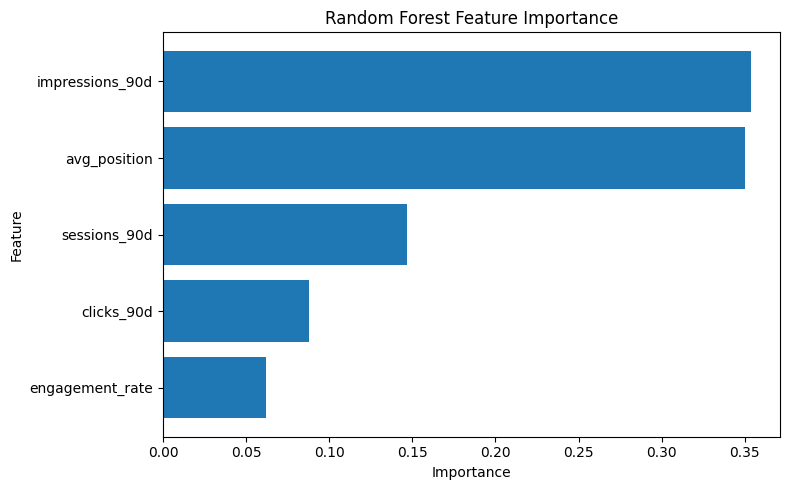

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [60]:
error_summary = pd.DataFrame({
    "Actual": test["actual"].value_counts(),
    "Predicted": test["model_prediction"].value_counts()
})

display(error_summary)

,Actual,Predicted
1,3252,3656
0,2748,2344


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.